# FastLearn campaign: short-range vs LES long-range on the same 80-frame split

Two model families, trained on the same 320-frame FastLearn water data, all at
**80,000 steps** with `batch_size: 2` (160 steps/epoch, so 500 epochs - the cace
schedule exactly):

| family | long-range term | charges |
|---|---|---|
| `deepmd` | none (SR control) | - |
| `deepmd-les` | latent Ewald | learned per-atom, initialised at SPC/E |
| `deepmd-les-claim-neutral` | latent Ewald | learned, projected neutral each frame |
| `deepmd-les-freeze-charge` | classical Ewald | fixed SPC/E table |

Each family has two replicates (`_sA`, `_sB`); the two cace arms (`cace-sr`,
`cace-lr`) each have one seed. Metrics are always at the **latest checkpoints**
(the campaign keeps 40k-80k) and always over the **full 80-frame validation
split**, never the `lcurve.out` columns - those are computed on 3 frames per
display step and cannot rank these arms.

Provenance: `campaign_fastlearn/` on the compshare pod, `run_campaign.sh`,
finished 2026-09-21 01:06 UTC. Configs from `deepmd/gen_inputs.py`; the cace arms
use the author's water-timing recipe via `cace/fit_cace.py`.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

HERE = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
DATA = os.path.join(HERE, 'data')
assert os.path.isdir(DATA), f'no data dir at {DATA} - run the notebook from analysis/'

# Categorical palette. Hue carries the FAMILY; replicate is carried by line
# style, never by colour.
#
# Validation, and the caveat that has to travel with it. Over the declared order
# as adjacent pairs every check passes (worst CVD dE 9.1, worst normal-vision
# dE 22.9, both at #eda100<->#1baf7a). Over --pairs all it FAILS the normal-vision
# floor: #eda100 <-> #eb6834 is dE 13.7, under the 15 hard floor, so the amber
# freeze-charge control and the orange learned-q arm are hard to tell apart even
# with full colour vision. They are non-adjacent in the declared order, which is
# why the adjacent sweep (and the earlier note here, which quoted the adjacent
# numbers as if they were all-pairs) missed it. Not fixed here: re-stepping amber
# repaints every figure in the report, so it is raised as its own decision.
#
# deepmd-les-init0-neutral deliberately shares claim-neutral's green instead of
# taking a fifth hue. It IS a claim-neutral arm - the one knob that differs is the
# anchor the charge net starts from - so it is one family at two anchors, and the
# anchor is carried by line style. A fifth hue could not pass anyway while amber
# and orange are both in use (above).
FAMILIES = ['deepmd', 'deepmd-les', 'deepmd-les-claim-neutral',
            'deepmd-les-init0-neutral', 'deepmd-les-freeze-charge']
LABELS = {
    'deepmd': 'SR only',
    'deepmd-les': 'LES: learned q',
    'deepmd-les-claim-neutral': 'LES: learned q, neutral',
    'deepmd-les-init0-neutral': 'LES: learned q, neutral, q0 = 0',
    'deepmd-les-freeze-charge': 'LES: fixed SPC/E q',
}
LUMA = {'deepmd': '#2a78d6', 'deepmd-les': '#eb6834',
        'deepmd-les-claim-neutral': '#1baf7a',
        'deepmd-les-init0-neutral': '#1baf7a',
        'deepmd-les-freeze-charge': '#eda100'}
LS = {'sA': '-', 'sB': (0, (5, 2))}
# Per-family style overrides; a family absent here falls back to LS. The init0 arm
# takes the two styles no other line uses, so its green is never ambiguous with
# claim-neutral's solid/dashed pair.
LS_FAM = {'deepmd-les-init0-neutral': {'sA': (0, (6, 2, 1, 2)), 'sB': (0, (2, 2))}}

def style(fam, rep):
    return LS_FAM.get(fam, LS)[rep]
SURFACE = '#fcfcfb'
INK, INK2, INK3 = '#0b0b0b', '#52514e', '#8a8981'

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': INK3, 'axes.linewidth': 0.8,
    'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 11, 'axes.labelsize': 9.5,
    'xtick.color': INK2, 'ytick.color': INK2,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'grid.color': '#e6e5e1', 'grid.linewidth': 0.7,
    'legend.frameon': False, 'legend.fontsize': 8.5,
    'font.size': 9.5, 'figure.dpi': 110,
})

def split_arm(arm):
    fam, _, rep = arm.rpartition('_s')
    return fam, 's' + rep

def tidy_grid(ax, title='', xlabel='', ylabel=''):
    ax.grid(True, which='major', alpha=0.9)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    if title:  ax.set_title(title, loc='left', pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)

print('families:', FAMILIES)

families: ['deepmd', 'deepmd-les', 'deepmd-les-claim-neutral', 'deepmd-les-freeze-charge']


## Load the data

Every number below comes from one of four artefacts:

- `data/lcurve/<arm>/lcurve.out` - the training display log (2 header lines, then
  `step rmse_val rmse_trn rmse_e_val rmse_e_trn rmse_f_val rmse_f_trn lr`).
- `data/valid_sweep.tsv` - `eval_campaign.py`, one row per (arm, checkpoint):
  `test_ener` over all 80 validation frames.
- `data/energy_decomp_{valid,train}.tsv` - `decompose_energy.py`, per-frame energy
  error split into level (bias) and shape (spread).
- `data/les_metrics.tsv` - parsed from each LES arm's verbose `les.log`.

In [2]:
LCOLS = ['step', 'rmse_val', 'rmse_trn', 'rmse_e_val', 'rmse_e_trn',
         'rmse_f_val', 'rmse_f_trn', 'lr']
frames = []
root = os.path.join(DATA, 'lcurve')
for arm in sorted(os.listdir(root)):
    p = os.path.join(root, arm, 'lcurve.out')
    if not os.path.exists(p):
        continue
    d = pd.read_csv(p, sep=r'\s+', comment='#', header=None, names=LCOLS)
    d['arm'] = arm
    d[['family', 'rep']] = d['arm'].apply(lambda a: pd.Series(split_arm(a)))
    frames.append(d)
lc = pd.concat(frames, ignore_index=True)
print('lcurve rows:', len(lc), '| arms:', lc['arm'].nunique(),
      '| steps to', int(lc['step'].max()))

sweep = pd.read_csv(os.path.join(DATA, 'valid_sweep.tsv'), sep='\t')
sweep[['family', 'rep']] = sweep['arm'].apply(lambda a: pd.Series(split_arm(a)))
dv = pd.read_csv(os.path.join(DATA, 'energy_decomp_valid.tsv'), sep='\t')
dt = pd.read_csv(os.path.join(DATA, 'energy_decomp_train.tsv'), sep='\t')
for d in (dv, dt):
    d[['family', 'rep']] = d['arm'].apply(lambda a: pd.Series(split_arm(a)))
les = pd.read_csv(os.path.join(DATA, 'les_metrics.tsv'), sep='\t')

# The cace arms live in their own TSV, produced by `cace/collect_sweep.py` on the
# pod. The figures below are written to run either way: an absent file leaves an
# empty frame with the right columns and HAVE_CACE False, so each cace figure
# skips with a message instead of dying on a NameError.
CACE_COLOR = '#4a4a48'          # deliberately outside the four-hue family system:
CACE_LABELS = {'cace-sr': 'cace: SR only',       # cace is a different code, not
               'cace-lr': 'cace: SR + Ewald q'}  # a fifth configuration of ours
CACE_COLS = ['arm', 'step', 'epoch', 'ckpt', 'val_selected', 'rmse_e_peratom',
             'rmse_f', 'natoms', 'nframes', 'e_r2', 'f_r2', 'bias', 'spread',
             'bias2_over_rmse2', 'f_lr_over_f_tot', 'f_self_over_f_tot',
             'e_lr_mean_ev_per_frame', 'e_lr_std_ev_per_frame',
             'e_self_ev_per_frame', 'net_charge_mean_per_frame',
             'sum_q2_mean_per_frame', 'self_term_ev_per_frame', 'self_over_e_lr',
             'remove_self_interaction', 'model_sha256_12']
_cace_path = os.path.join(DATA, 'cace_valid.tsv')
if os.path.exists(_cace_path):
    cace = pd.read_csv(_cace_path, sep='\t')
else:
    cace = pd.DataFrame(columns=CACE_COLS)
# best_model.pth was selected on this same 80-frame split, so it is reported but
# never enters a mean: the phase checkpoints are the evenly spaced ones.
cace_stat = cace[cace['val_selected'] == 0].copy()
HAVE_CACE = len(cace_stat) > 0
cace_mean = (cace_stat.groupby('arm')[['rmse_f', 'rmse_e_peratom', 'bias', 'spread']]
             .mean()) if HAVE_CACE else pd.DataFrame(columns=['rmse_f'])
print('cace rows:', len(cace),
      '| arms:', sorted(cace['arm'].unique()) if len(cace) else [],
      '| flagged val-selected:', int(cace['val_selected'].sum()) if len(cace) else 0)
print('sweep rows:', len(sweep), '| decompositions:', len(dv), len(dt),
      '| les log rows:', len(les))
sweep.head(3)

lcurve rows: 648 | arms: 8 | steps to 80000
cace rows: 10 | arms: ['cace-lr', 'cace-sr'] | flagged val-selected: 2
sweep rows: 40 | decompositions: 8 8 | les log rows: 4818


,arm,step,rmse_e_peratom,rmse_f,natoms,nframes,family,rep
0,deepmd_sA,40000,0.000778,0.056278,192,80,deepmd,sA
1,deepmd_sA,50000,0.000534,0.056085,192,80,deepmd,sA
2,deepmd_sA,60000,0.000698,0.056040,192,80,deepmd,sA


## FIG 1 - Learning curves

`rmse_f` on the validation split (left) and the training split (right). Both
panels share one y-axis - they are the same quantity on different data, so they
must not get two scales.

The logged validation columns come from `numb_btch: 3` frames, so the *level* of
these curves is noisy; what they are good for is shape - when each arm converges,
and whether the ranking is stable. The y-axis is logarithmic because the data
spans 1.5 decades (0.85 eV/A at step 1 down to 0.05), which means the 5-6% gap
between families is deliberately NOT readable here - that comparison is FIG 2,
on a zoomed linear axis. Note the schedule: `decay_steps 5000` over 80,000 steps
is a 16-level staircase from 1e-3 to 3.51e-8, so the flat tail is real
convergence, not a squashed lr axis.

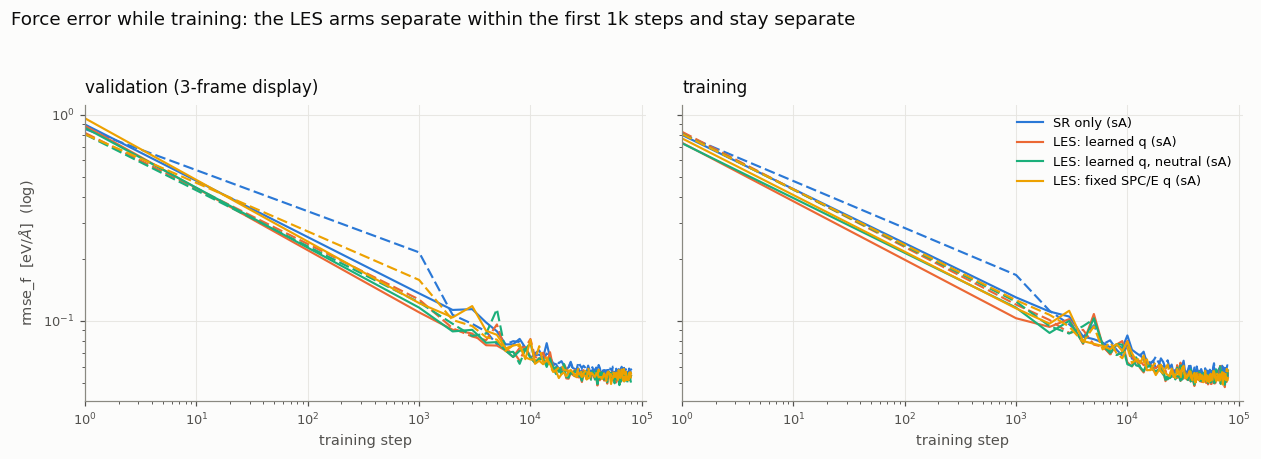

In [3]:
def curves(ax, key, ylabel, title, logy=False, ylim=None):
    for fam in FAMILIES:
        for rep in ('sA', 'sB'):
            d = lc[(lc['family'] == fam) & (lc['rep'] == rep)].sort_values('step')
            if d.empty:
                continue
            ax.plot(d['step'], d[key], color=LUMA[fam], ls=style(fam, rep), lw=1.4,
                    label=f'{LABELS[fam]} ({rep})' if rep == 'sA' else None)
    ax.set_xscale('log')
    ax.set_xlim(1, 1.1e5)
    if logy:
        ax.set_yscale('log')
    if ylim:
        ax.set_ylim(*ylim)
    tidy_grid(ax, title, 'training step', ylabel)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
curves(axes[0], 'rmse_f_val', 'rmse_f  [eV/$\\AA$]  (log)',
       'validation (3-frame display)', logy=True)
curves(axes[1], 'rmse_f_trn', '', 'training', logy=True)
axes[1].legend(loc='upper right', ncol=2)
fig.suptitle('Force error while training: the LES arms separate within the first 1k steps and stay separate',
             x=0.007, ha='left', fontsize=12, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

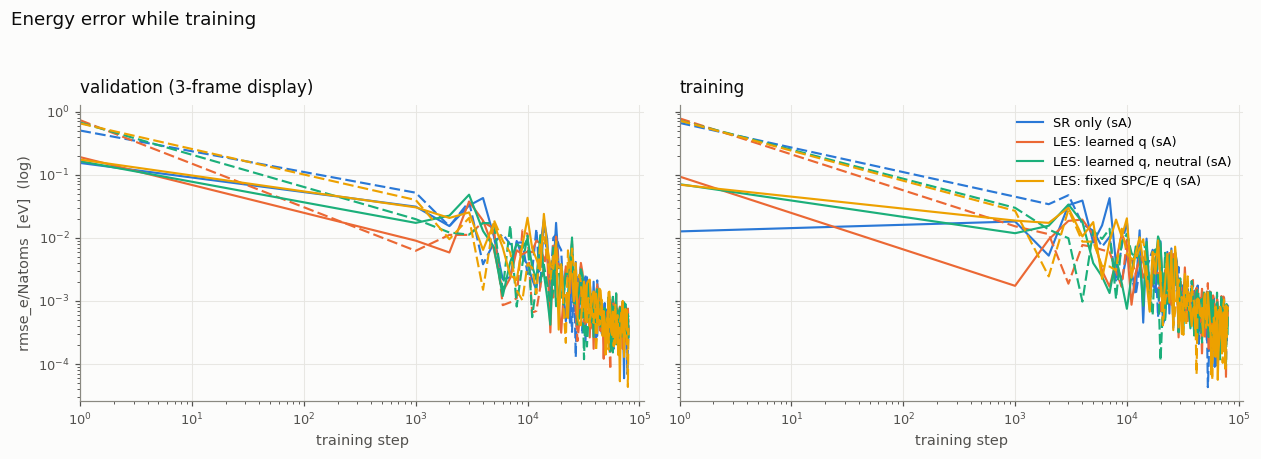

In [4]:
# Same two panels for the energy column. The energies sit on a large constant
# offset (the fitting bias absorbs the atomic-energy reference), so the LEVEL of
# these curves is not interpretable as accuracy - FIG 3 is where that is priced.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
curves(axes[0], 'rmse_e_val', 'rmse_e/Natoms  [eV]  (log)',
       'validation (3-frame display)', logy=True)
curves(axes[1], 'rmse_e_trn', '', 'training', logy=True)
axes[1].legend(loc='upper right', ncol=2)
fig.suptitle('Energy error while training', x=0.007, ha='left', fontsize=12, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## FIG 2 - Final metrics over the full validation split

`lcurve.out` cannot rank these arms. This is the same question asked properly:
each arm scored on **all 80 validation frames** at each of its five kept late
checkpoints. Each dot is one checkpoint; the rule is the mean.

The two panels deliberately use **different** aggregation, because the two
measures have different convergence behaviour (FIG 2b shows it): force is flat
across the five checkpoints, so averaging them only removes noise, while energy is
still descending at 80,000 for *every* arm including the SR control, so averaging
that window would report a number describing no checkpoint the campaign actually
trained. Energy therefore quotes the final checkpoint alone.

Replicate spread is the yardstick - two seeds of the same configuration differ by
roughly 0.1-2.8% on force, which is the smallest difference worth reading.

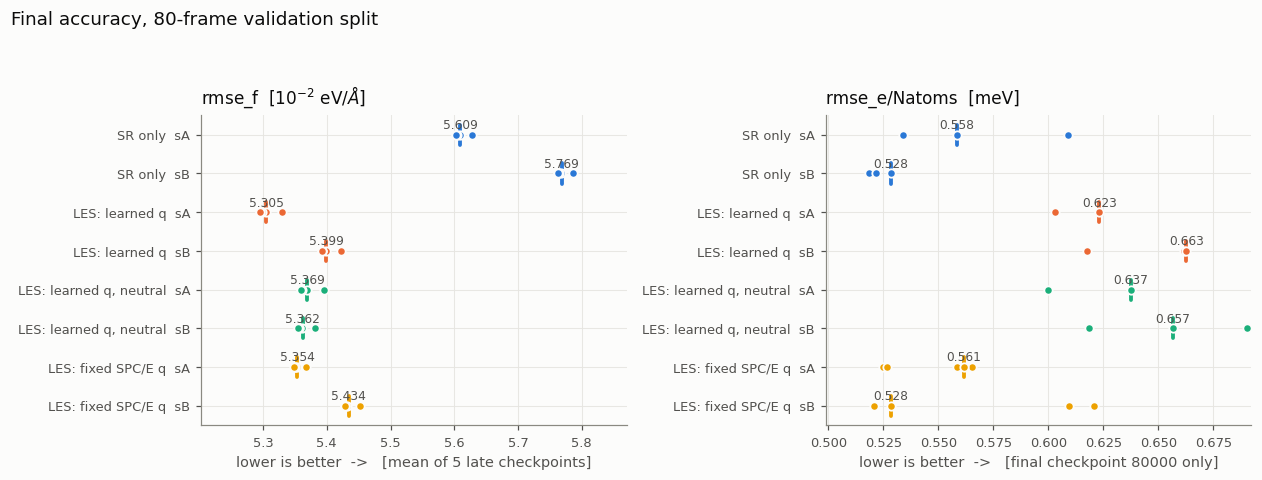

arm                               rmse_f (mean5)   vs SR  rmse_e 80k [meV]   vs SR
deepmd_sA                            5.60904e-02   -1.4%            0.5584   +2.7%
deepmd_sB                            5.76869e-02   +1.4%            0.5285   -2.7%
deepmd-les_sA                        5.30475e-02   -6.8%            0.6231  +14.7%
deepmd-les_sB                        5.39946e-02   -5.1%            0.6628  +22.0%
deepmd-les-claim-neutral_sA          5.36924e-02   -5.6%            0.6374  +17.3%
deepmd-les-claim-neutral_sB          5.36222e-02   -5.7%            0.6567  +20.8%
deepmd-les-freeze-charge_sA          5.35375e-02   -5.9%            0.5615   +3.3%
deepmd-les-freeze-charge_sB          5.43424e-02   -4.5%            0.5283   -2.8%

clean separation on force (mean5): worst LES 5.43424e-02 < best SR-only 5.60904e-02  ->  True


In [5]:
late = sweep[sweep['step'] == sweep['step'].max()]
avg5 = (sweep.groupby(['family', 'arm', 'rep'])[['rmse_f', 'rmse_e_peratom']]
        .mean().reset_index())
avg80 = (late.groupby(['family', 'arm', 'rep'])[['rmse_f', 'rmse_e_peratom']]
         .mean().reset_index())
order = [a for f in FAMILIES for a in sorted(avg5[avg5['family'] == f]['arm'])]
avg5 = avg5.set_index('arm').loc[order].reset_index()
avg80 = avg80.set_index('arm').loc[order].reset_index()

PANELS = [('rmse_f', avg5, 'mean of 5 late checkpoints',
           'rmse_f  [$10^{-2}$ eV/$\\AA$]', 1e2),
          ('rmse_e_peratom', avg80, 'final checkpoint 80000 only',
           'rmse_e/Natoms  [meV]', 1e3)]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for ax, (col, tab, rule, lab, scale) in zip(axes, PANELS):
    for i, row in tab.iterrows():
        pts = sweep[sweep['arm'] == row['arm']][col] * scale
        ax.scatter(pts, np.full(len(pts), i), s=30, color=LUMA[row['family']],
                   zorder=3, edgecolor=SURFACE, linewidth=1.2)
        ax.plot([row[col] * scale] * 2, [i - 0.26, i + 0.26],
                color=LUMA[row['family']], lw=2.5, solid_capstyle='round', zorder=2)
        ax.text(row[col] * scale, i - 0.42, f'{row[col] * scale:.3f}',
                ha='center', va='top', fontsize=8, color=INK2)
    ax.set_yticks(np.arange(len(tab)))
    ax.set_yticklabels([f"{LABELS[row['family']]}  {row['rep']}"
                        for _, row in tab.iterrows()], fontsize=8.5)
    ax.set_ylim(len(tab) - 0.5, -0.5)          # reversed: best family on top
    lo, hi = (tab[col] * scale).min(), (tab[col] * scale).max()
    pad = (hi - lo) * 0.22
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_xlabel(f'lower is better  ->   [{rule}]')
    # linear and zoomed. A dot plot (not bars) is what makes a truncated axis
    # legitimate: the mark is a point, not a length measured from zero.
    tidy_grid(ax, lab, '', '')
fig.suptitle('Final accuracy, 80-frame validation split',
             x=0.007, ha='left', fontsize=12, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

base5 = avg5[avg5['family'] == 'deepmd']['rmse_f'].mean()
base80 = avg80[avg80['family'] == 'deepmd']['rmse_e_peratom'].mean()
print(f'{"arm":32s} {"rmse_f (mean5)":>15s} {"vs SR":>7s} '
      f'{"rmse_e 80k [meV]":>17s} {"vs SR":>7s}')
for a in order:
    f = avg5.set_index('arm').loc[a, 'rmse_f']
    e = avg80.set_index('arm').loc[a, 'rmse_e_peratom']
    print(f'{a:32s} {f:15.5e} {(f-base5)/base5*100:+6.1f}% '
          f'{e*1e3:17.4f} {(e-base80)/base80*100:+6.1f}%')
sr_f = avg5[avg5['family'] == 'deepmd']['rmse_f']
les_f = avg5[avg5['family'] != 'deepmd']['rmse_f']
print(f'\nclean separation on force (mean5): worst LES {les_f.max():.5e} < '
      f'best SR-only {sr_f.min():.5e}  ->  {bool(les_f.max() < sr_f.min())}')

## FIG 2b - The same metric at every kept checkpoint

This is what justifies the two different aggregations above. `rmse_f` is flat from
40,000 to 80,000 for every arm (drift -0.3% to -0.7%, and the last-two-checkpoint
mean is within 0.2% of the last-five), so the force ranking is a converged result.
`rmse_e` is still falling steeply for every arm over the same window - even the
SR-only control drops 28-30% - so no energy number here is a converged result, and
the learned-charge arms' energy disadvantage is a moving target rather than a
settled gap.

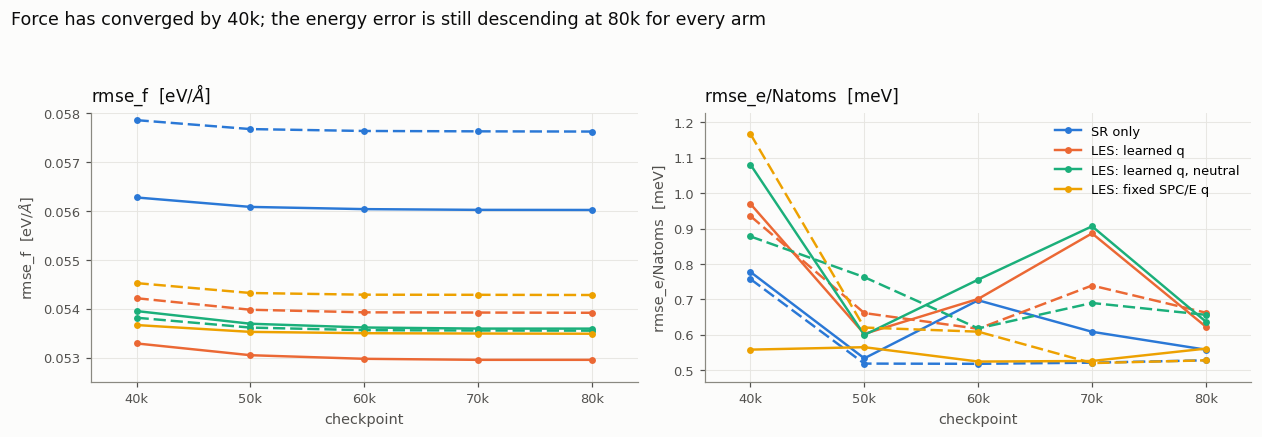

force drift 40k -> 80k, and last-5 vs last-2 mean:
  deepmd-les-claim-neutral_sA       -0.67%   last2 vs last5 -0.18%
  deepmd-les-claim-neutral_sB       -0.49%   last2 vs last5 -0.12%
  deepmd-les-freeze-charge_sA       -0.33%   last2 vs last5 -0.08%
  deepmd-les-freeze-charge_sB       -0.45%   last2 vs last5 -0.10%
  deepmd-les_sA                     -0.63%   last2 vs last5 -0.17%
  deepmd-les_sB                     -0.55%   last2 vs last5 -0.13%
  deepmd_sA                         -0.45%   last2 vs last5 -0.12%
  deepmd_sB                         -0.40%   last2 vs last5 -0.10%
energy drift 40k -> 80k:
  deepmd-les-claim-neutral_sA      -41.02%
  deepmd-les-claim-neutral_sB      -25.20%
  deepmd-les-freeze-charge_sA       +0.52%
  deepmd-les-freeze-charge_sB      -54.72%
  deepmd-les_sA                    -35.75%
  deepmd-les_sB                    -29.15%
  deepmd_sA                        -28.21%
  deepmd_sB                        -30.26%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharex=True)
for fam in FAMILIES:
    for rep in ('sA', 'sB'):
        d = sweep[(sweep['family'] == fam) & (sweep['rep'] == rep)].sort_values('step')
        if d.empty:
            continue
        axes[0].plot(d['step'], d['rmse_f'], color=LUMA[fam], ls=style(fam, rep), lw=1.6,
                     marker='o', ms=3.5, label=f'{LABELS[fam]} ({rep})' if rep == 'sA' else None)
        axes[1].plot(d['step'], d['rmse_e_peratom'] * 1e3, color=LUMA[fam],
                     ls=style(fam, rep), lw=1.6, marker='o', ms=3.5,
                     label=LABELS[fam] if rep == 'sA' else None)
for ax, lab in zip(axes, ['rmse_f  [eV/$\\AA$]', 'rmse_e/Natoms  [meV]']):
    ax.set_xlabel('checkpoint')
    tidy_grid(ax, lab, 'checkpoint', lab)
axes[0].set_xlim(3.6e4, 8.4e4)
axes[0].set_xticks([40000, 50000, 60000, 70000, 80000])
axes[0].set_xticklabels(['40k', '50k', '60k', '70k', '80k'])
axes[0].set_ylim(5.25e-2, 5.80e-2)
_e = sweep['rmse_e_peratom'] * 1e3
axes[1].set_ylim(_e.min() * 0.90, _e.max() * 1.05)   # meV, matching what was plotted
axes[1].legend(loc='upper right')
fig.suptitle('Force has converged by 40k; the energy error is still descending at 80k for every arm',
             x=0.007, ha='left', fontsize=11.5, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

drift = sweep.pivot_table(index='arm', columns='step', values='rmse_f')
print('force drift 40k -> 80k, and last-5 vs last-2 mean:')
for a, r in drift.iterrows():
    v = r.dropna()
    print(f'  {a:32s} {(v.iloc[-1]-v.iloc[0])/v.iloc[0]*100:+6.2f}%   '
          f'last2 vs last5 {(v.iloc[-2:].mean()-v.iloc[-5:].mean())/v.iloc[-5:].mean()*100:+.2f}%')
dre = sweep.pivot_table(index='arm', columns='step', values='rmse_e_peratom')
print('energy drift 40k -> 80k:')
for a, r in dre.iterrows():
    v = r.dropna()
    print(f'  {a:32s} {(v.iloc[-1]-v.iloc[0])/v.iloc[0]*100:+6.2f}%')

## FIG 3 - Is the energy gap a level shift or a shape problem?

A raw energy RMSE in this project is misleading: the model's fitting bias absorbs
a large constant offset (the SPC/E atomic-energies reuse; deepmd's own reference),
so a worse raw RMSE can mean nothing more than a shifted level. `decompose_energy.py`
answers it on the per-frame errors: `bias` is the level, `spread` is the shape, and
`bias^2/rmse^2` is the share of the error that a constant could explain.

Here that share is 3-20% for every arm, so a constant absorbs only a minority of
the error.

The argument deliberately does not lean on the fitted `rmse_cal` column, because
that column is not trustworthy in every file: the train-split TSV was produced with
an uncentered fit, which is rank-deficient on these near-constant targets and
returns a residual *above* the spread. It is not needed either. Since
`rmse_cal = spread * sqrt(1 - rho^2)`, a linear recalibration can never do better
than the spread itself, so comparing spreads is already the optimistic bound on
what any re-levelling could buy.

The two components are drawn side by side, not stacked: they do not add as lengths.
What adds is `rmse^2 = bias^2 + spread^2`, so a stacked bar would misstate the
geometry. Side by side, the visual claim is the honest one - the faded level bars
are around a third the height of the shape bars, for every arm.

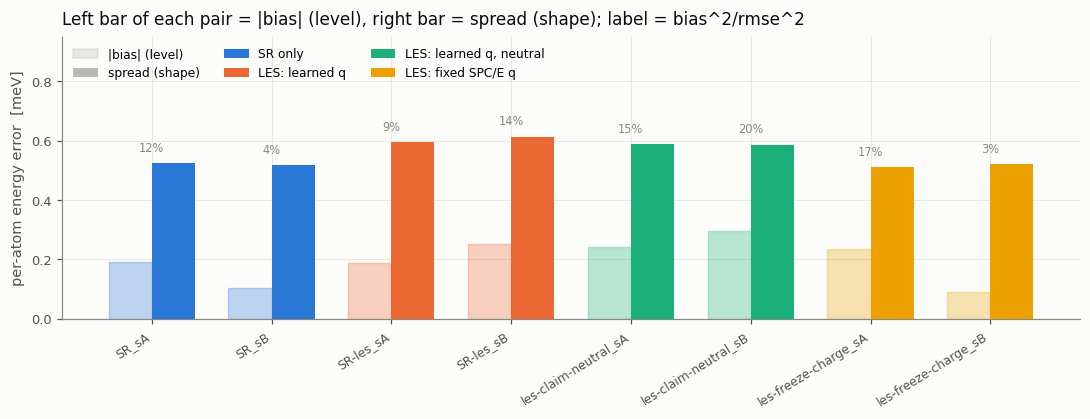

                        arm       rmse        bias     spread   rmse_cal
                  deepmd_sA 5.5836e-04 -1.9283e-04 5.2400e-04 5.2281e-04
                  deepmd_sB 5.2847e-04 -1.0526e-04 5.1788e-04 5.1782e-04
              deepmd-les_sA 6.2314e-04 -1.8887e-04 5.9382e-04 5.9120e-04
              deepmd-les_sB 6.6277e-04 -2.5201e-04 6.1299e-04 6.1040e-04
deepmd-les-claim-neutral_sA 6.3737e-04 -2.4334e-04 5.8909e-04 5.8639e-04
deepmd-les-claim-neutral_sB 6.5668e-04 -2.9591e-04 5.8623e-04 5.8333e-04
deepmd-les-freeze-charge_sA 5.6147e-04 -2.3339e-04 5.1066e-04 5.1008e-04
deepmd-les-freeze-charge_sB 5.2834e-04 -9.1642e-05 5.2034e-04 5.2033e-04
  rmse_cal <= rmse (valid): True
  rmse_cal <= rmse (train): True  frames per arm: [320]

bias^2/rmse^2 share: SR_sA=12%  SR_sB=4%  SR-les_sA=9%  SR-les_sB=14%  SR-les-claim-neutral_sA=15%  SR-les-claim-neutral_sB=20%  SR-les-freeze-charge_sA=17%  SR-les-freeze-charge_sB=3%


In [7]:
fig, ax = plt.subplots(figsize=(10.0, 3.9))
d = dv.set_index('arm').loc[[a for a in avg5['arm'] if a in set(dv['arm'])]].reset_index()
x = np.arange(len(d))
w = 0.36
for i, row in d.iterrows():
    c = LUMA[row['family']]
    # |bias| = the level error a constant could absorb; spread = the shape error.
    ax.bar(i - w / 2, abs(row['bias']) * 1e3, width=w, color=c, alpha=0.30,
           edgecolor=c, linewidth=0.9)
    ax.bar(i + w / 2, row['spread'] * 1e3, width=w, color=c)
    ax.text(i, max(abs(row['bias']), row['spread']) * 1e3 + 0.03,
            f"{row['bias']**2 / row['rmse']**2 * 100:.0f}%", ha='center',
            va='bottom', fontsize=7.5, color=INK3)
ax.set_xticks(x)
ax.set_xticklabels([a.replace('deepmd-les-', 'les-').replace('deepmd', 'SR')
                    for a in d['arm']], rotation=32, ha='right', fontsize=8)
# headroom so the legend never lands on the tallest bar's annotation
ax.set_ylim(0, max(abs(d['spread']).max(), abs(d['bias']).max()) * 1e3 * 1.55)
# legend: shape/level explained once, family hues explained once, in one row.
gh = [mpatches.Patch(facecolor='#b9b8b3', alpha=0.30, edgecolor='#b9b8b3',
                     label='|bias| (level)'),
      mpatches.Patch(facecolor='#b9b8b3', label='spread (shape)')]
gh += [mpatches.Patch(facecolor=LUMA[f], label=LABELS[f]) for f in FAMILIES
       if f in set(d['family'])]
tidy_grid(ax, 'Left bar of each pair = |bias| (level), right bar = spread (shape); label = bias^2/rmse^2',
          '', 'per-atom energy error  [meV]')
ax.legend(handles=gh, loc='upper left', ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

print(d[['arm', 'rmse', 'bias', 'spread', 'rmse_cal']].to_string(index=False,
      float_format=lambda v: f'{v:.4e}'))
# The fitted affine family contains a=1, b=0, so its least-squares residual can
# never exceed the raw rmse: rmse_cal <= rmse is the invariant. It is also the one
# that fails loudly when the fit is degenerate. (rmse_cal <= spread is NOT an
# invariant - a=0 is not in the family - and the pre-fix train column was once
# mis-cited against it.) decompose_energy.py now asserts the real invariant, so a
# violation printed here means the TSV predates that check and should be rebuilt.
print('  rmse_cal <= rmse (valid):',
      bool((d['rmse_cal'] <= d['rmse'] * 1.000000001).all()))
_dtc = dt[dt['arm'].isin(d['arm'])]
print('  rmse_cal <= rmse (train):',
      bool((_dtc['rmse_cal'] <= _dtc['rmse'] * 1.000000001).all()),
      ' frames per arm:', sorted(set(_dtc['nframes'])))
print('\nbias^2/rmse^2 share:',
      '  '.join(f"{r['arm'].replace('deepmd','SR')}={r['bias']**2 / r['rmse']**2 * 100:.0f}%"
               for _, r in d.iterrows()))

## FIG 4 - LES diagnostics: is the charge channel actually learning?

From each LES arm's verbose log (every 100 steps): the per-species mean latent
charge, and the norm of each layer of the charge net. The `freeze-charge` arm is
the reference line - its charges are the SPC/E table by construction, so any
movement in the other arms is the network and not the initialisation.

Both learned-charge families start exactly at SPC/E (`+0.4238` / `-0.8476`) and
then grow the magnitude of the charges.

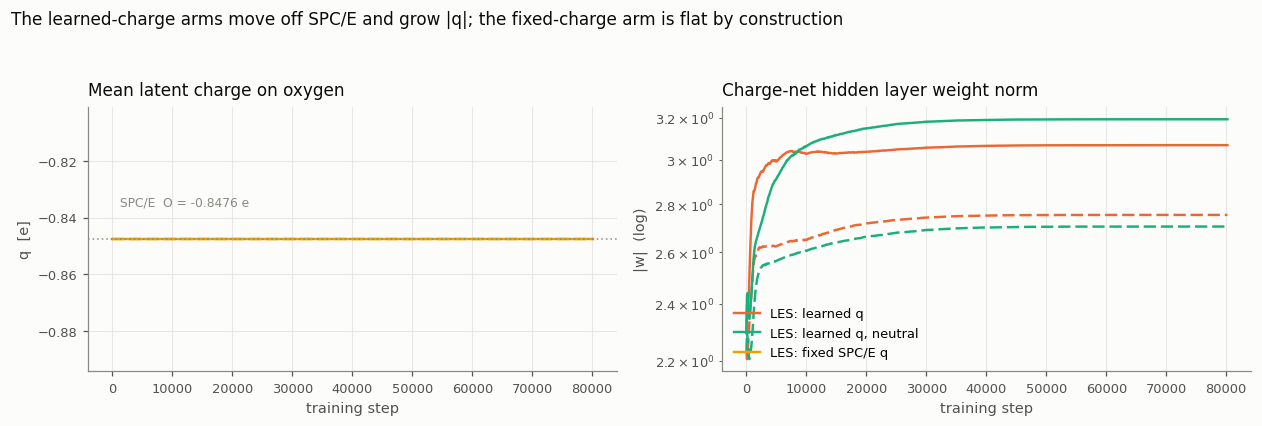

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
for fam in ('deepmd-les', 'deepmd-les-claim-neutral',
            'deepmd-les-init0-neutral', 'deepmd-les-freeze-charge'):
    for rep in ('sA', 'sB'):
        d = les[(les['arm'] == f'{fam}_s{rep[-1]}')].sort_values('step')
        if d.empty:
            continue
        axes[0].plot(d['step'], d['qO_mean'], color=LUMA[fam], ls=style(fam, rep), lw=1.6,
                     label=LABELS[fam] if rep == 'sA' else None)
        axes[1].plot(d['step'], d['w_outnet.1_weight'], color=LUMA[fam],
                     ls=style(fam, rep), lw=1.6, label=LABELS[fam] if rep == 'sA' else None)
axes[0].axhline(-0.8476, color=INK3, lw=1.0, ls=(0, (1, 2)))
axes[0].text(1.2e3, -0.8476 + 0.012, 'SPC/E  O = -0.8476 e', fontsize=8, color=INK3)
tidy_grid(axes[0], 'Mean latent charge on oxygen', 'training step', 'q  [e]')
axes[1].set_yscale('log')
tidy_grid(axes[1], 'Charge-net hidden layer weight norm',
          'training step', '|w|  (log)')
axes[1].legend(loc='lower right')  # the |w| curves rise, so the bottom-right is the one free corner
fig.suptitle('The learned-charge arms move off SPC/E and grow |q|; the fixed-charge arm is flat by construction',
             x=0.007, ha='left', fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## FIG 5 - What the long-range channel is actually contributing

`E_lr` as logged. This is the figure that explains the campaign's oddest number:
the long-range energy is **positive and small** (+10.9 to +22.7 eV/frame at the
first log, +11.6 to +18.0 at the end) when the same Ewald sum run with the
physical convention is about -385 eV on a validation frame with SPC/E charges.

The cause is `remove_self_interaction: False`, which the campaign inherited from
the author's cace recipe (`campaign_fastlearn/cace/fit_cace.py` passes it
explicitly, and it is cace's default). With it off, the kernel keeps a
self-interaction term

    E_self = norm_factor / (sigma * (2*pi)^1.5) * sum_i q_i^2  =  +5.7446 eV * sum q^2

which is a large positive quantity that nearly cancels the physical sum. At SPC/E
on one frame, `sum q^2 = 68.97`, so that term is `+396.2 eV` against a physical
`-384.8 eV`, leaving `+11.4 eV`.

Three independent checks agree:

- The `freeze-charge` replicates log `+10.93` and `+11.26 eV` at their first
  checkpoint (their charges are the SPC/E table, so this is the same arithmetic
  on the same chemistry) - a few percent from the `+11.43 eV` I computed
  standalone, the gap being a 2-frame batch mean and the net's own rounding.
- les `remove_self_interaction=True` gives `-384.77 eV` and `False` gives
  `+11.43 eV` on the identical frame and charges - a flip of 396.2 eV, which is
  `5.7446 x 68.97` to five digits.
- cace's own kernel, in its own units, gives `+0.1263` / `-4.2528`; times the
  90.0474 conversion that is `+11.37` / `-382.9 eV`. The flag is a faithful
  mirror of the cace reference, not a porting error.

The right panel plus the printed table show why this is not a constant: the
logged charges grow (std 0.5995 -> ~0.78), so `sum q^2` grows from ~69 to
~106-117 and the self term from ~397 to ~660 eV. The physical Ewald sum grows
negative by about the same amount, which is why the *logged* `E_lr` stays small.

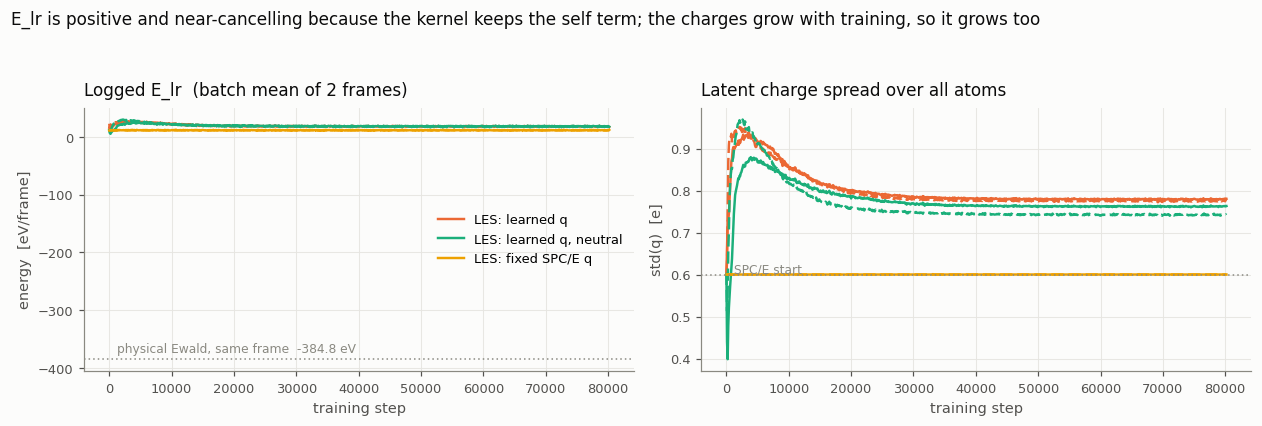

                             q_std_first  q_std_last  sum_q2_first  sum_q2_last  self_eV_first  self_eV_last
arm                                                                                                         
deepmd-les-claim-neutral_sA        0.600       0.763        69.014      111.777        396.458       642.114
deepmd-les-claim-neutral_sB        0.604       0.742        70.107      105.667        402.734       607.017
deepmd-les-freeze-charge_sA        0.600       0.600        69.149       69.149        397.233       397.233
deepmd-les-freeze-charge_sB        0.600       0.600        69.149       69.149        397.233       397.233
deepmd-les_sA                      0.600       0.780        69.777      116.960        400.839       671.890
deepmd-les_sB                      0.604       0.774        72.950      115.231        419.070       661.957

analytic SPC/E sum q^2 = 68.97 at 192 atoms/frame; logged step-1 values above are within a few % of it, which is what validates

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
for fam in ('deepmd-les', 'deepmd-les-claim-neutral',
            'deepmd-les-init0-neutral', 'deepmd-les-freeze-charge'):
    for rep in ('sA', 'sB'):
        d = les[les['arm'] == f'{fam}_s{rep[-1]}'].sort_values('step')
        if d.empty:
            continue
        axes[0].plot(d['step'], d['e_lr_mean'], color=LUMA[fam], ls=style(fam, rep), lw=1.6,
                     label=LABELS[fam] if rep == 'sA' else None)
        axes[1].plot(d['step'], d['q_std'], color=LUMA[fam], ls=style(fam, rep), lw=1.6,
                     label=LABELS[fam] if rep == 'sA' else None)
axes[0].axhline(-384.77, color=INK3, lw=1.0, ls=(0, (1, 2)))
axes[0].text(1.2e3, -384.77 + 12, 'physical Ewald, same frame  -384.8 eV',
             fontsize=8, color=INK3)
tidy_grid(axes[0], 'Logged E_lr  (batch mean of 2 frames)', 'training step',
          'energy  [eV/frame]')
axes[1].axhline(0.5995, color=INK3, lw=1.0, ls=(0, (1, 2)))
axes[1].text(1.2e3, 0.605, 'SPC/E start', fontsize=8, color=INK3)
tidy_grid(axes[1], 'Latent charge spread over all atoms', 'training step',
          'std(q)  [e]')
axes[0].legend(loc='center right')
fig.suptitle('E_lr is positive and near-cancelling because the kernel keeps the self term; the charges grow with training, so it grows too',
             x=0.007, ha='left', fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

# The artifact scales the logged E_lr: E_lr = E_physical + 5.7446 * sum q^2, and
# sum q^2 = 192 atoms/frame * (std^2 + mean^2) since mean is ~0 for neutral frames.
les['sum_q2'] = 192 * (les['q_std'] ** 2 + les['q_mean'] ** 2)
les['self_term'] = 5.7446 * les['sum_q2']
tab = les.groupby('arm').agg(q_std_first=('q_std', 'first'),
                             q_std_last=('q_std', 'last'),
                             sum_q2_first=('sum_q2', 'first'),
                             sum_q2_last=('sum_q2', 'last'),
                             self_eV_first=('self_term', 'first'),
                             self_eV_last=('self_term', 'last'))
print(tab.to_string(float_format=lambda v: f'{v:8.3f}'))
# Analytic cross-check: 64 O x (-0.8476)^2 + 128 H x (0.4238)^2 = 68.97.
spce = 64 * 0.8476 ** 2 + 128 * 0.4238 ** 2
print(f'\nanalytic SPC/E sum q^2 = {spce:.2f} at 192 atoms/frame; '
      f'logged step-1 values above are within a few % of it, which is what '
      f'validates the 192-atom scaling and the 5.7446 eV coefficient.')

## FIG 6 - cace, on the same 80 frames and the same axes

The other implementation in this comparison, trained on the same 320 frames by the author's own water recipe (`cace/fit_cace.py`).
`cace-sr` is a short-range head straight to the energy; `cace-lr` adds a charge head and an `EwaldPotential`, summed by `FeatureAdd` at unit weight.
Each arm is a single seed, so it has no replicate spread of its own.

The split is the campaign's `xyz/valid.xyz`, which is geometry-identical to the deepmd arms' `data_3`: 80 frames, 192 atoms, `max |dpos|` 5.0e-9 A and `max |dcell|` 0.
That residual is the xyz text carrying fewer decimals than float64, not a different frame set, and `score_cace.py` re-derives it on every run and reports it rather than trusting a file name.
`train.xyz` is likewise exactly `data_0` + `data_1` (both `set.000` and `set.001`) + `data_2`, and shares no frame with the validation set, so neither split leaks into the other.

The two codes do not keep checkpoints the same way, so the two halves of each panel are not the same rule.
deepmd keeps its last five checkpoints (40k-80k steps; at `batch_size: 2` over 320 frames that is 160 steps per epoch, so epochs 250-500); cace writes one at each phase end (epochs 200, 300, 400, 500).
`best_model.pth` is a fifth cace checkpoint, selected by validation loss *within the final phase* on these same 80 frames, so it is drawn as an open diamond and left out of the cace mean.
Including a checkpoint picked on the scored set would flatter cace by an amount nobody can bound.

The printed `vs SR-only` column compares both cace arms against the deepmd short-range control, which is a cross-code comparison.
Read it with the Findings cell: `cace-sr` has no long-range term and still beats every deepmd arm, so that column measures the descriptor and the recipe, not the long-range physics.


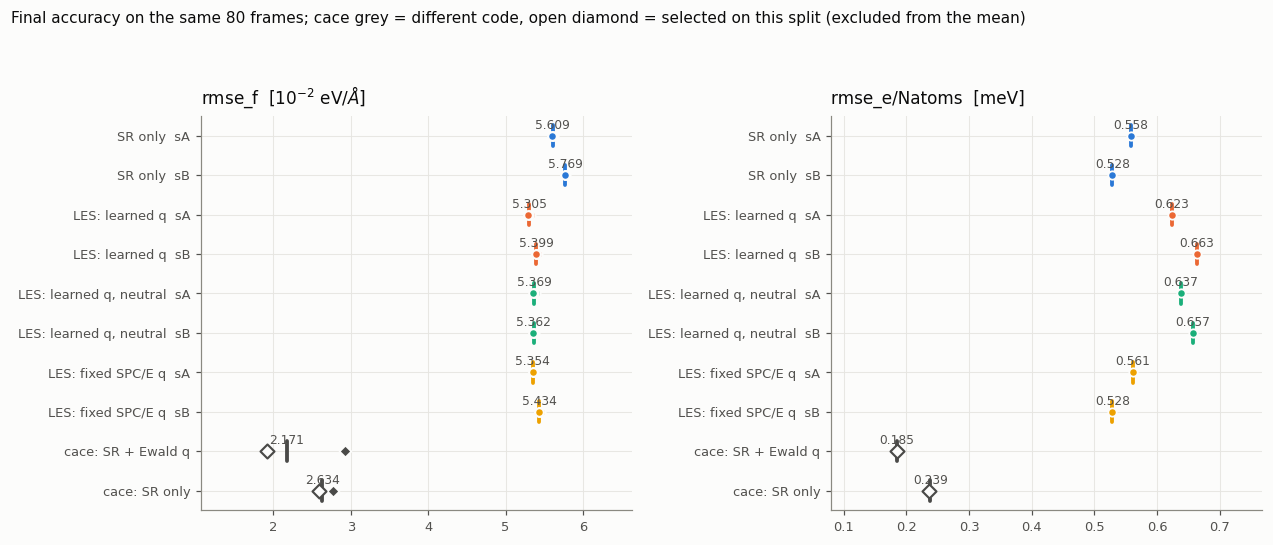

arm        rmse_f (late mean)  vs SR-only    rmse_e 500 [meV]
cace-lr           2.17105e-02      -61.8%              0.1852
cace-sr           2.63450e-02      -53.7%              0.2385

best deepmd arm 5.30475e-02  vs  best cace arm 2.17105e-02  ->  cace better by 59.1%

NOTE: one seed each, 4 phase checkpoints against deepmd's 5 late ones; this ranks implementations, not hyperparameters.


In [10]:
if not HAVE_CACE:
    print('SKIP FIG 6: no cace_valid.tsv yet (run cace/collect_sweep.py on the pod)')
else:
    # force: each code averaged over the checkpoints it keeps late in training.
    # energy: the final checkpoint of each code, matching FIG 2's second panel.
    # both deepmd frames carry `arm` as a column (cell 9 resets the index), so
    # they are re-indexed here to match the `mean.loc[arm, col]` access below
    CACE_TAB = {'rmse_f': (avg5.set_index('arm'), cace_mean),
                'rmse_e_peratom': (avg80.set_index('arm'),
                                   cace_stat[cace_stat['epoch'] == 500]
                                   .set_index('arm'))}
    CACE_PTS = {'rmse_f': (sweep, cace_stat),
                'rmse_e_peratom': (late, cace_stat[cace_stat['epoch'] == 500])}

    entries = []
    for fam in FAMILIES:
        for arm in sorted(avg5[avg5['family'] == fam]['arm']):
            entries.append((f'{LABELS[fam]}  {arm[-2:]}', LUMA[fam], 'o', arm, fam))
    for arm in sorted(cace_mean.index):
        entries.append((CACE_LABELS[arm], CACE_COLOR, 'D', arm, 'cace'))
    row = {e[0]: i for i, e in enumerate(entries)}

    fig, axes = plt.subplots(1, 2, figsize=(11.6, 5.0))
    for ax, col, lab, scale in ((axes[0], 'rmse_f', 'rmse_f  [$10^{-2}$ eV/$\\AA$]', 1e2),
                                (axes[1], 'rmse_e_peratom', 'rmse_e/Natoms  [meV]', 1e3)):
        dtab, ctab = CACE_TAB[col]
        dpts, cpts = CACE_PTS[col]
        plotted = []
        for label, colour, marker, arm, kind in entries:
            pts = cpts if kind == 'cace' else dpts
            mean = ctab if kind == 'cace' else dtab
            i = row[label]
            p = pts[pts['arm'] == arm][col] * scale
            plotted.append(p.values)
            ax.scatter(p, np.full(len(p), i), s=30, color=colour, marker=marker,
                       zorder=3, edgecolor=SURFACE, linewidth=1.2)
            m = mean.loc[arm, col] * scale
            ax.plot([m, m], [i - 0.26, i + 0.26], color=colour, lw=2.5,
                    solid_capstyle='round', zorder=2)
            ax.text(m, i - 0.44, f'{m:.3f}', ha='center', va='top', fontsize=8,
                    color=INK2)
        # the validation-selected checkpoint: visible, but outside the mean bar
        for arm in sorted(cace_mean.index):
            sel = cace[(cace['arm'] == arm) & (cace['val_selected'] == 1)][col] * scale
            ax.scatter(sel, np.full(len(sel), row[CACE_LABELS[arm]]), s=42,
                       facecolor=SURFACE, edgecolor=CACE_COLOR, linewidth=1.4,
                       marker='D', zorder=4)
        allv = np.concatenate(plotted)
        pad = (allv.max() - allv.min()) * 0.22
        ax.set_yticks(np.arange(len(entries)))
        ax.set_yticklabels([e[0] for e in entries], fontsize=8.5)
        ax.set_ylim(len(entries) - 0.5, -0.5)
        ax.set_xlim(allv.min() - pad, allv.max() + pad)
        tidy_grid(ax, lab, '', '')
    fig.suptitle('Final accuracy on the same 80 frames; cace grey = different code, open diamond = selected on this split (excluded from the mean)',
                 x=0.007, ha='left', fontsize=10, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

    base5 = avg5[avg5['family'] == 'deepmd']['rmse_f'].mean()
    print(f'{"arm":10s} {"rmse_f (late mean)":>18s} {"vs SR-only":>11s}   '
          f'{"rmse_e 500 [meV]":>17s}')
    for arm in sorted(cace_mean.index):
        f = cace_mean.loc[arm, 'rmse_f']
        e = CACE_TAB['rmse_e_peratom'][1].loc[arm, 'rmse_e_peratom']
        print(f'{arm:10s} {f:18.5e} {(f - base5) / base5 * 100:+10.1f}%   {e * 1e3:17.4f}')
    best_les = avg5[avg5['family'] != 'deepmd']['rmse_f'].min()
    print(f'\nbest deepmd arm {best_les:.5e}  vs  best cace arm '
          f'{cace_mean["rmse_f"].min():.5e}  ->  cace better by '
          f'{(1 - cace_mean["rmse_f"].min() / best_les) * 100:.1f}%')
    print('\nNOTE: one seed each, 4 phase checkpoints against deepmd\'s 5 late ones; '
          'this ranks implementations, not hyperparameters.')


## FIG 7 - Is the full-split number converged, for every arm?

FIG 1 answers this for deepmd only, and from the 3-frame columns of `lcurve.out`.
This is the same full-split RMSE as FIG 6, but against training progress, so an arm that is still improving at its last checkpoint shows up as a slope instead of hiding inside a mean.

The x-axis is epochs: both codes ran 160 steps per epoch here (320 frames at `batch_size: 2`), so deepmd's 40k-80k checkpoints are epochs 250-500 and cace's phase checkpoints are epochs 200-500.
The deepmd lines are the mean over the two replicates; each cace line is a single seed, so its movement mixes in nothing but training progress.


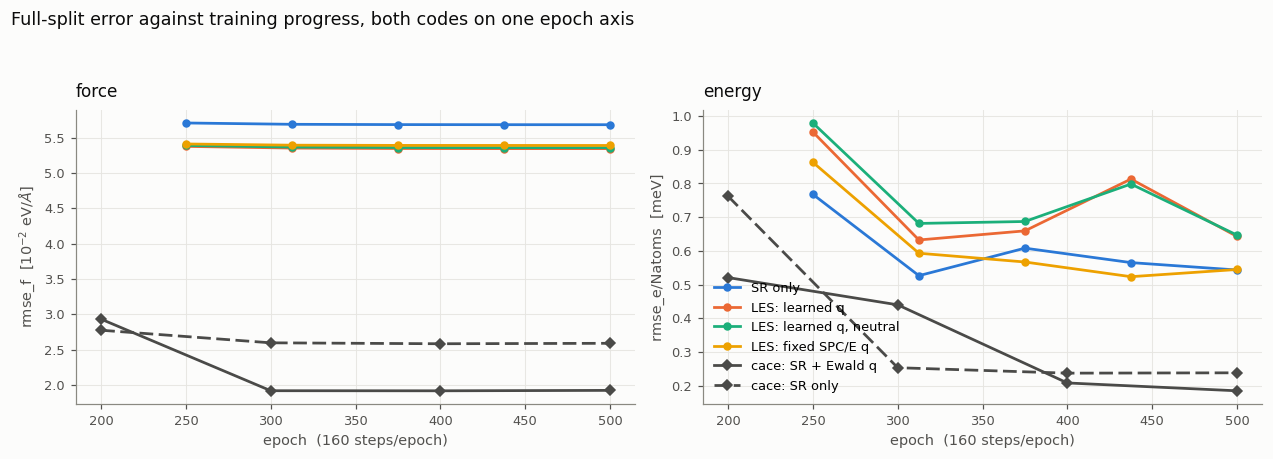

change in rmse_f over the last two kept checkpoints, per arm:
  deepmd-les-claim-neutral_sA       -0.00%
  deepmd-les-claim-neutral_sB       -0.01%
  deepmd-les-freeze-charge_sA       -0.01%
  deepmd-les-freeze-charge_sB       -0.01%
  deepmd-les_sA                     +0.00%
  deepmd-les_sB                     -0.01%
  deepmd_sA                         -0.00%
  deepmd_sB                         -0.01%
  cace-lr                           +0.31%   (one seed)
  cace-sr                           +0.25%   (one seed)


In [11]:
if not HAVE_CACE:
    print('SKIP FIG 7: no cace_valid.tsv yet')
else:
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))
    d7 = sweep.copy()
    d7['epoch'] = d7['step'] / 160.0
    for fam in FAMILIES:
        g = d7[d7['family'] == fam].groupby('epoch')[['rmse_f', 'rmse_e_peratom']].mean()
        if g.empty:
            continue  # no full-split sweep for this arm, so no line and no legend entry
        axes[0].plot(g.index, g['rmse_f'] * 1e2, color=LUMA[fam], lw=1.8, marker='o',
                     ms=4.5, label=LABELS[fam])
        axes[1].plot(g.index, g['rmse_e_peratom'] * 1e3, color=LUMA[fam], lw=1.8,
                     marker='o', ms=4.5, label=LABELS[fam])
    for arm in sorted(cace_mean.index):
        g = cace_stat[cace_stat['arm'] == arm].sort_values('epoch')
        ls = '-' if arm == 'cace-lr' else (0, (5, 2))
        axes[0].plot(g['epoch'], g['rmse_f'] * 1e2, color=CACE_COLOR, lw=1.8,
                     marker='D', ms=4.5, ls=ls, label=CACE_LABELS[arm])
        axes[1].plot(g['epoch'], g['rmse_e_peratom'] * 1e3, color=CACE_COLOR, lw=1.8,
                     marker='D', ms=4.5, ls=ls, label=CACE_LABELS[arm])
    tidy_grid(axes[0], 'force', 'epoch  (160 steps/epoch)',
              'rmse_f  [$10^{-2}$ eV/$\\AA$]')
    tidy_grid(axes[1], 'energy', 'epoch  (160 steps/epoch)', 'rmse_e/Natoms  [meV]')
    axes[1].legend(loc='best')
    fig.suptitle('Full-split error against training progress, both codes on one epoch axis',
                 x=0.007, ha='left', fontsize=11.5, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

    print('change in rmse_f over the last two kept checkpoints, per arm:')
    for arm, r in d7.pivot_table(index='arm', columns='epoch', values='rmse_f').iterrows():
        v = r.dropna()
        if len(v) >= 2:
            print(f'  {arm:32s} {(v.iloc[-1] - v.iloc[-2]) / v.iloc[-2] * 100:+6.2f}%')
    for arm in sorted(cace_mean.index):
        g = cace_stat[cace_stat['arm'] == arm].sort_values('epoch')
        print(f'  {arm:32s} '
              f'{(g["rmse_f"].iloc[-1] - g["rmse_f"].iloc[-2]) / g["rmse_f"].iloc[-2] * 100:+6.2f}%'
              '   (one seed)')


## FIG 8 - cace's own training trace

cace's loss cannot share an axis with FIG 1: it is one weighted combination of its own terms (`FORCE_WEIGHT 1000` against the energy term), not an RMSE in eV or eV/A.
On its own scale it is still worth showing, because it makes the checkpoint protocol visible: the steps at epochs 200, 300 and 400 are phase boundaries, where the energy weight goes 0.1 -> 1 -> 10 -> 1000 while the force weight stays fixed.
The four phase checkpoints are therefore four different objectives rather than four points on one curve, and the last is energy-dominated relative to the first.
Each epoch is printed twice in the log, a bare line and a timestamped one, and only the timestamped copy carries the phase context, which is the form `score_cace.py` anchors on when it parses the trace.


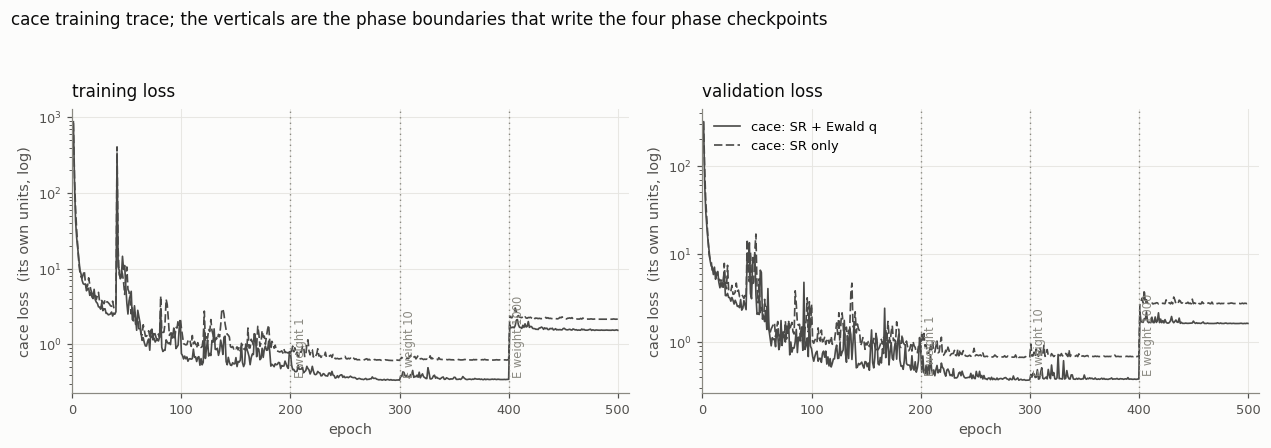

         epochs  first  last  val_first  val_last
arm                                              
cace-lr     500      1   500    317.065    1.6340
cace-sr     500      1   500    316.563    2.7674


In [12]:
CACE_EP = os.path.join(DATA, 'cace_epoch_metrics.tsv')
if not os.path.exists(CACE_EP):
    print('SKIP FIG 8: no', CACE_EP, '- never collected')
else:
    ep = pd.read_csv(CACE_EP, sep='\t')
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.1))
    for arm in sorted(ep['arm'].unique()):
        d = ep[ep['arm'] == arm].sort_values('global_epoch')
        ls = '-' if arm == 'cace-lr' else (0, (5, 2))
        axes[0].plot(d['global_epoch'], d['train_loss'], color=CACE_COLOR,
                     lw=1.1, ls=ls, label=CACE_LABELS.get(arm, arm))
        axes[1].plot(d['global_epoch'], d['val_loss'], color=CACE_COLOR,
                     lw=1.1, ls=ls, label=CACE_LABELS.get(arm, arm))
    for ax, t in zip(axes, ('training loss', 'validation loss')):
        ax.set_yscale('log')
        lo = ax.get_ylim()[0]
        for e, w in ((200, '1'), (300, '10'), (400, '1000')):
            ax.axvline(e, color=INK3, lw=0.9, ls=(0, (1, 3)))
            ax.text(e + 4, lo * 1.6, f'E weight {w}', fontsize=7.5, color=INK3,
                    rotation=90, va='bottom', ha='left')
        ax.set_xlim(0, ep['global_epoch'].max() * 1.02)
        tidy_grid(ax, t, 'epoch', 'cace loss  (its own units, log)')
    axes[1].legend(loc='best')
    fig.suptitle('cace training trace; the verticals are the phase boundaries that write the four phase checkpoints',
                 x=0.007, ha='left', fontsize=11, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()
    print(ep.groupby('arm').agg(epochs=('global_epoch', 'count'),
                                first=('global_epoch', 'min'),
                                last=('global_epoch', 'max'),
                                val_first=('val_loss', 'first'),
                                val_last=('val_loss', 'last')).to_string())


## FIG 9 - What each code puts into the long-range channel

Two dimensionless force shares, because the two codes' charge scales are not comparable: cace's `norm_factor` is 1.0 while les hardcodes the physical 90.4756, so a cace charge of 1 is about 9.5 physical charges.
Ratios survive that; absolute energies do not, which is why neither panel here plots an energy in eV.

**Left: how much of the total force is the long-range term.**
For les this is exact rather than approximate: `lr_weight` scales `E_lr` above the coordinate gradient that produces the long-range force, so `lr_weight = 0` removes that force and nothing else, and `F_LR = F(w=1) - F(w=0)` with the short-range net untouched in both evaluations.
Nothing is retrained, so this is the decomposition the trained model actually uses.

**Right: how much of the total force is the self-interaction term the kernel keeps.**
Both codes keep it (`remove_self_interaction: False`, cace's own default and passed explicitly by the author's recipe), and this prices its gradient by flipping the flag and differencing the total force.
The term is `+norm_factor / (sigma * (2*pi)^1.5) * sum q^2`, so for a learned charge it depends on geometry through `dq/dr` and is a genuine force, while for per-type constant charges its gradient is identically zero.
That is the prediction the fixed-charge arm tests, and it is the only arm here whose charges cannot move.

**A self share above 1.0 is not an error, and the fixed-charge zeros are the test.**
The learned-charge arms read 1.01-1.31 on the right panel, which is impossible for a
component of a total unless the pieces cancel, and here they do. The Ewald force is
`F_LR = F_physical + F_self`, so `F_self` is not bounded by `F_tot`; when the physical
part cancels most of it, the kept self force can exceed the whole net force. A share
of 1.31 says the spurious force is larger than the net force and dominant inside the
long-range channel, not that the arithmetic is wrong.
Both `freeze-charge` arms read exactly zero on that same measurement (`~1e-15`), which
is the prediction for per-type constants and the reason this panel is worth drawing at
all: one family exercises the mechanism and the other cannot.

`cace-sr` appears in neither panel: it has no long-range channel at all, which is exactly what makes it the control for whether the `cace-lr` result comes from the Ewald term rather than from the extra parameters.


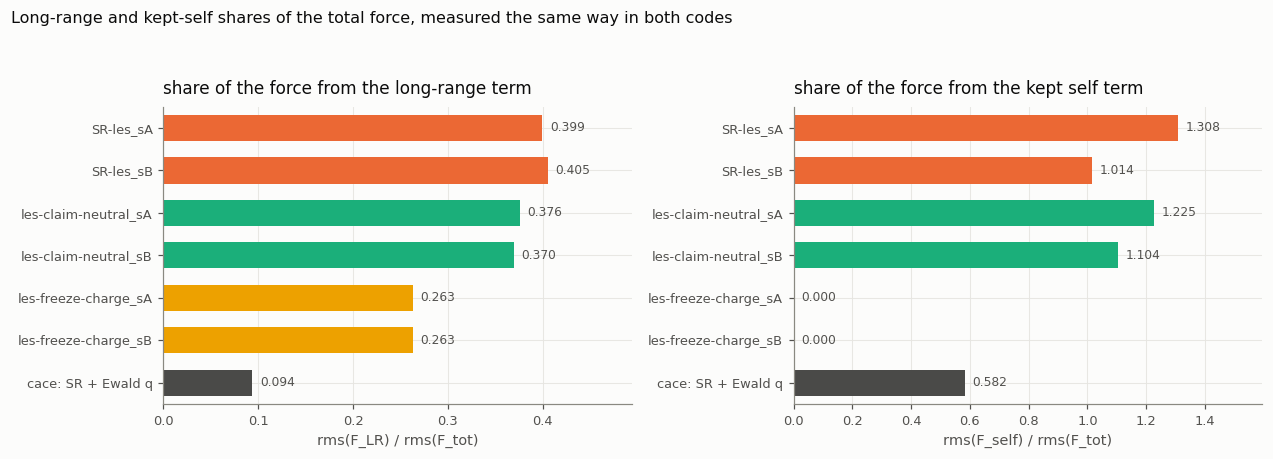

                 arm  F_LR_over_F_tot  F_self_over_F_tot
           SR-les_sA         0.399437       1.307757e+00
           SR-les_sB         0.405246       1.014337e+00
les-claim-neutral_sA         0.375802       1.225395e+00
les-claim-neutral_sB         0.369596       1.103736e+00
les-freeze-charge_sA         0.263171       1.093653e-15
les-freeze-charge_sB         0.263083       1.155961e-15
  cace: SR + Ewald q         0.093672       5.823236e-01

les raw rows:
                        arm  e_lr_mean  e_self_mean   f_self_rms  f_tot_rms  rsi_trained
              deepmd-les_sA  17.998594   668.873084 1.066807e+00   0.815753            0
              deepmd-les_sB  17.978489   661.427986 8.271438e-01   0.815453            0
deepmd-les-claim-neutral_sA  18.351182   639.155717 9.995760e-01   0.815717            0
deepmd-les-claim-neutral_sB  17.552256   606.230337 8.998504e-01   0.815277            0
deepmd-les-freeze-charge_sA  11.420086   396.200299 8.920055e-16   0.815620         

In [13]:
if not HAVE_CACE:
    print('SKIP FIG 9: no cace_valid.tsv yet')
else:
    lm = pd.read_csv(os.path.join(DATA, 'lr_mechanism_les.tsv'), sep='\t')
    rows = [(a.replace('deepmd-les-', 'les-').replace('deepmd', 'SR'),
             LUMA[split_arm(a)[0]], float(v), float(s))
            for a, v, s in zip(lm['arm'], lm['f_lr_over_f_tot'], lm['f_self_over_f_tot'])]
    for arm in sorted(cace_mean.index):
        d = cace_stat[cace_stat['arm'] == arm]
        if d['f_lr_over_f_tot'].notna().any():
            rows.append((CACE_LABELS[arm], CACE_COLOR,
                         float(d['f_lr_over_f_tot'].mean()),
                         float(d['f_self_over_f_tot'].mean())))
    labels = [r[0] for r in rows]
    y = np.arange(len(rows))
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))
    for ax, idx, t, xl in ((axes[0], 2, 'share of the force from the long-range term',
                            'rms(F_LR) / rms(F_tot)'),
                           (axes[1], 3, 'share of the force from the kept self term',
                            'rms(F_self) / rms(F_tot)')):
        vals = [r[idx] for r in rows]
        ax.barh(y, vals, color=[r[1] for r in rows], height=0.62)
        for i, v in enumerate(vals):
            ax.text(v + max(vals) * 0.02, y[i], f'{v:.3f}', va='center', ha='left',
                    fontsize=8, color=INK2)
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8.5)
        ax.set_ylim(len(y) - 0.5, -0.5)
        ax.set_xlim(0, max(vals) * 1.22)
        tidy_grid(ax, t, xl, '')
    fig.suptitle('Long-range and kept-self shares of the total force, measured the same way in both codes',
                 x=0.007, ha='left', fontsize=10.5, color=INK)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()
    print(pd.DataFrame(rows, columns=['arm', 'family', 'F_LR_over_F_tot',
                                      'F_self_over_F_tot']).drop(columns='family')
          .to_string(index=False))
    print('\nles raw rows:')
    print(lm[['arm', 'e_lr_mean', 'e_self_mean', 'f_self_rms', 'f_tot_rms',
              'rsi_trained']].to_string(index=False))


## Findings

**Force - a converged result.** Every LES variant beats the SR-only control, and
the separation is clean: the worst LES run (5.428e-02) is better than the best
SR-only run (5.602e-02). Family means are SR-only 5.689e-02, learned q 5.352e-02
(-5.9%), learned-and-neutral 5.366e-02 (-5.7%), fixed SPC/E q 5.394e-02 (-5.2%).
Replicate spread inside a family is 0.1-2.8%, so the effect is 2-50x the noise
floor. FIG 2b shows the drift over 40k-80k is under 1%, so this ranking is not an
artefact of where the run stopped.

**The interesting negative result.** Fixed SPC/E charges do as well as learned
charges (5.394e-02 vs 5.352e-02, a 0.8% gap against a 2.8% replicate spread
inside the SR control). Learning the charges buys nothing measurable on force at
this configuration. Constraining them to sum to zero changes nothing either.

**Energy - provisional, and deliberately not quoted as a mean.** The learned-charge
arms are worse on energy, but this is the one result the campaign cannot settle.
`rmse_e` is still descending at 80,000 for every arm - the SR-only control itself
falls 28-30% from 40k to 80k, and the learned-charge arms about the same - so no
energy number here is converged. At the final checkpoint the ranking is SR-only
5.434e-04, learned q 6.430e-04 (+18%), learned-and-neutral 6.470e-04 (+19%),
fixed SPC/E q 5.449e-04 (+0.3%), on a per-atom energy scale. The gap is also
narrowing as training continues (24% at 40k to 18% at 80k), so a longer run could
change it. Averaging the five late checkpoints inflates the gap to +23-26% purely
because the earlier checkpoints in the window are worse - which is why that
average is not reported.

**Bias versus shape.** The decomposition at 80,000 splits the error into a level
term and a shape term. `bias^2/rmse^2` is 3-20% for every arm, so the level is a
minority of the error everywhere, and a linear recalibration barely moves the number.
Comparing shapes, the learned-charge arms are 13-16% worse than SR-only while the
fixed-charge arm is 1% better. If the energy gap is real, it is a fit-quality
difference, not a shifted reference.

**Why that pairing is not a surprise.** The term kept by
`remove_self_interaction: False` is a function of the charges. For `freeze-charge`
the charges are per-type constants, so the term is a constant offset that the
fitting bias absorbs for free. For the learned-charge arms the charges depend on
geometry, so the same term injects a geometry-dependent force into the long-range
channel. Measured over all 80 validation frames by flipping the kernel flag, that
force is 0.83-1.07 eV/A per component rms, or **1.01-1.31x the total force rms** - it
is not a small correction but a force comparable to the whole net force, which is
possible only because the physical Ewald force nearly cancels it (see FIG 9). On both
`freeze-charge` arms the same flip moves the force by 1e-15 eV/A, exactly zero, as the
constant-charge argument predicts. So the mechanism is half verified by construction:
one family exercises it, the other cannot. It remains a plausible account of the
pattern observed - learned charges pay, fixed charges do not - but the campaign has no
arm that removes the term to price it, so this is a mechanism that fits, not one that
has been shown to cause the gap.

**Cross-code, and why it is not an accuracy verdict.** The cace arms land about
2.5x better on force than the best LES arm (cace-lr 2.1711e-02 against 5.3048e-02),
and that factor must not be read as "LES is worse". The labels are bit-identical, so
the one remaining difference is the descriptor (deepmd `se_a` with `sel` [39, 73] and
`rcut` 5.5 against cace's `n_atom_basis` 3, `n_radial_basis` 12, `max_l` 3, `max_nu` 3
at the same cutoff). The decisive evidence is the control: `cace-sr` has no long-range
term at all, yet at 2.6345e-02 it beats every one of the eight deepmd arms. The
cross-code gap is therefore a property of the descriptor and the training recipe, not
of the physics under study. What survives as a finding is the within-code ablation, and
the two codes agree in sign. Within cace, `cace-lr` beats `cace-sr` on force by 17.6%
on the four phase checkpoints (2.1711e-02 vs 2.6345e-02) - and by 25.9% over epochs
300-500 alone. That spread is itself informative: cace-lr's epoch-200 checkpoint
(2.930e-02) is its worst, from the phase whose energy weight is still 0.1, so the
long-range head is a liability early and a large win once its charges train. Within
deepmd, LES beats its short-range control by 5.9% on force (5.689e-02 -> 5.352e-02).
Both deltas are positive; their size is architecture-dependent. Energy is not quoted
across codes at all: cace-sr's energy is converged by epoch 300 and cace-lr's is still
falling at 500 (1.85e-04 at the last checkpoint against a 3.387e-04 four-checkpoint
mean), the same non-convergence the deepmd learned-charge arms show.

**What this campaign cannot say.** There is no `remove_self_interaction: True`
control arm, so the cost of the flag is not priced here (the flag is shared by all
six LES arms, which keeps arm-vs-arm and les-vs-cace comparisons internally
consistent). The FastLearn data is a narrow fixed-cell set: the total energy
span is 3.96 eV over the 320 training frames (standard deviation 0.65 eV), which is
why the energy result is fragile and the force result is not. Each deepmd family has two
seeds, so differences under roughly 3% are not resolvable there; each cace arm has one,
so the cross-code factor of 2.5 is an order of magnitude, not a measurement. And the
cross-code comparison is confounded by the descriptor end to end: with `cace-sr` beating
every deepmd LES arm without any long-range term, the confound is larger than the effect
under study, so only the within-code ablations above are interpretable.

## Appendix - how these figures are encoded

Hue carries the **family** (four categorical slots, in fixed order, never cycled);
replicate is carried by line style (`sA` solid, `sB` dashed) so that identity never
rests on colour alone. The four hues are the validated default categorical palette
(`#2a78d6`, `#eb6834`, `#1baf7a`, `#eda100` on a `#fcfcfb` surface): all adjacent
pairs clear the CVD separation floor and the normal-vision floor.

The validator also reports a contrast WARN - the aqua and yellow slots sit below
3:1 against this surface. That warn is not dismissable, so it is relieved two
ways: every figure carries a legend in ink (text never wears the series colour),
and every figure's underlying numbers are in the TSVs under `data/` - the table
view. The ranked comparison in FIG 2 additionally prints the family name on each
row's axis label, so identity there is literal text, not colour.

Two deliberate choices worth stating: the learning curves use a log y-axis
because the data spans 1.5 decades, which is exactly why they are *not* the place
to read the 5-6% family gap; and FIG 2's x-axis is linear and zoomed to the data
range, which a dot plot (rather than a bar) legitimises - the mark is a point,
not a length measured from zero.